# Strategy 2: Post-Speech Momentum — Exit Timing Variants

Tests whether holding the position longer captures more alpha from Fed speeches.
Three exit variants, same entry (T-45min), same signal (trailing\_5\_avg ±10), flat sizing:
- **T+3hr**: current baseline exit (speech\_ts + 180min)
- **EOD**: exit at 16:59 ET same day
- **Next-day 10am**: exit at 10:00 ET next business day

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END   = "2026-06-30"
HAWK_THRESH = 10
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1

VARIANTS = {
    "T+3hr (baseline)": {"mode": "offset", "minutes": 180},
    "EOD (16:59)":      {"mode": "eod"},
    "Next-day 10am":    {"mode": "next_day"},
}
COLORS = {"T+3hr (baseline)": "#2980b9", "EOD (16:59)": "#e67e22", "Next-day 10am": "#27ae60"}

print("Config loaded.")

Config loaded.


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
jpm = jpm.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN = sorted(jpm["speaker"].unique())
print(f"JPM speakers: {len(KNOWN)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
JPM speakers: 23


## 2. Engine Setup

In [3]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

_t5_cache = {}
for speaker, grp in jpm.groupby("speaker"):
    g = grp.sort_values("date")
    _t5_cache[speaker] = (g["date"].values, g["trailing_5_avg"].values)

def get_t5(speaker, as_of):
    if speaker not in _t5_cache: return np.nan
    dates, vals = _t5_cache[speaker]
    mask = dates < np.datetime64(as_of)
    return float(vals[mask][-1]) if mask.any() else np.nan

def cap_exit_safe(exit_ts, entry_ts):
    # Cap exit to a valid trading timestamp
    exit_date = exit_ts.date()
    eq = ql.Date(exit_date.day, exit_date.month, exit_date.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        # Roll back to entry day close
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

def next_bday_10am(speech_ts):
    # Next business day 10:00 ET
    d = speech_ts.date() + datetime.timedelta(days=1)
    dql = ql.Date(d.day, d.month, d.year)
    if not ql_cal.isBusinessDay(dql):
        dql = ql_cal.advance(dql, ql.Period(1, ql.Days), ql.Following)
    nd = datetime.date(dql.year(), dql.month(), dql.dayOfMonth())
    return NYC_tz.localize(datetime.datetime.combine(nd, datetime.time(10, 0)))

print("Engine ready.")

Engine ready.


## 3. Build Events & Run Backtests

In [4]:
def build_events(variant_cfg):
    mode = variant_cfg["mode"]
    events = []
    for _, row in fed_speak_df.iterrows():
        speaker = extract_speaker(row["Title"])
        if speaker not in KNOWN: continue
        ts = row["TimestampNYC"]
        if pd.isna(ts): continue
        if ts.tzinfo is None: ts = NYC_tz.localize(ts)
        if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH: continue
        if is_in_blackout(ts.date()): continue
        if "press conference" in row["Title"].lower(): continue
        t5 = get_t5(speaker, ts.date())
        if pd.isna(t5): continue
        if t5 >= HAWK_THRESH:
            d = 1
        elif t5 <= -HAWK_THRESH:
            d = -1
        else:
            continue
        entry = ts - ENTRY_OFFSET
        eq = ql.Date(entry.day, entry.month, entry.year)
        if not ql_cal.isBusinessDay(eq): continue

        if mode == "offset":
            exit_ = ts + datetime.timedelta(minutes=variant_cfg["minutes"])
            exit_ = cap_exit_safe(exit_, entry)
        elif mode == "eod":
            exit_ = NYC_tz.localize(datetime.datetime.combine(ts.date(), datetime.time(16, 59)))
            if exit_ <= entry:
                exit_ = entry + datetime.timedelta(minutes=30)
                exit_ = cap_exit_safe(exit_, entry)
        elif mode == "next_day":
            exit_ = next_bday_10am(ts)
        else:
            continue

        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "t5": t5, "bpv": -d * BASE_BPV,
            "tag": f"e_{len(events)}",
        })
    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last: continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt


def run_bt(events, label):
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "direction": ev["direction"], "t5": ev["t5"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label}")
    bt.run()
    return bt


def extract_closed(bt):
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    cl["speaker"] = cl["source_query"].apply(lambda q: q.meta["speaker"])
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["t5"] = cl["source_query"].apply(lambda q: q.meta["t5"])
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"], utc=True).dt.tz_convert("America/New_York")
    cl["closed_at"] = pd.to_datetime(cl["closed_at"], utc=True).dt.tz_convert("America/New_York")
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl


all_closed = {}
for name, cfg in VARIANTS.items():
    print(f"\n--- {name} ---")
    evts = build_events(cfg)
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"  Events: {len(evts)} (hawk={n_h}, dove={n_d})")
    bt = run_bt(evts, name)
    cl = extract_closed(bt)
    all_closed[name] = cl
    print(f"  Closed: {len(cl)}, Cum: {cl['pnl_bps'].sum():+.1f} bps")

print("\nAll variants complete.")


--- T+3hr (baseline) ---


  Events: 461 (hawk=386, dove=75)


  T+3hr (baseline):   0%|          | 0/916 [00:00<?, ?step/s]

  T+3hr (baseline):   0%|          | 1/916 [00:00<08:34,  1.78step/s]

  T+3hr (baseline):   0%|          | 4/916 [00:00<02:05,  7.29step/s]

...

  Next-day 10am:  99%|█████████▉| 688/695 [00:36<00:00, 20.70step/s]

  Next-day 10am:  99%|█████████▉| 691/695 [00:36<00:00, 22.55step/s]

  Next-day 10am: 100%|█████████▉| 694/695 [00:36<00:00, 22.51step/s]

  Next-day 10am: 100%|██████████| 695/695 [00:36<00:00, 18.93step/s]

  Closed: 347, Cum: +217.5 bps

All variants complete.


## 4. Equity Curve Overlay

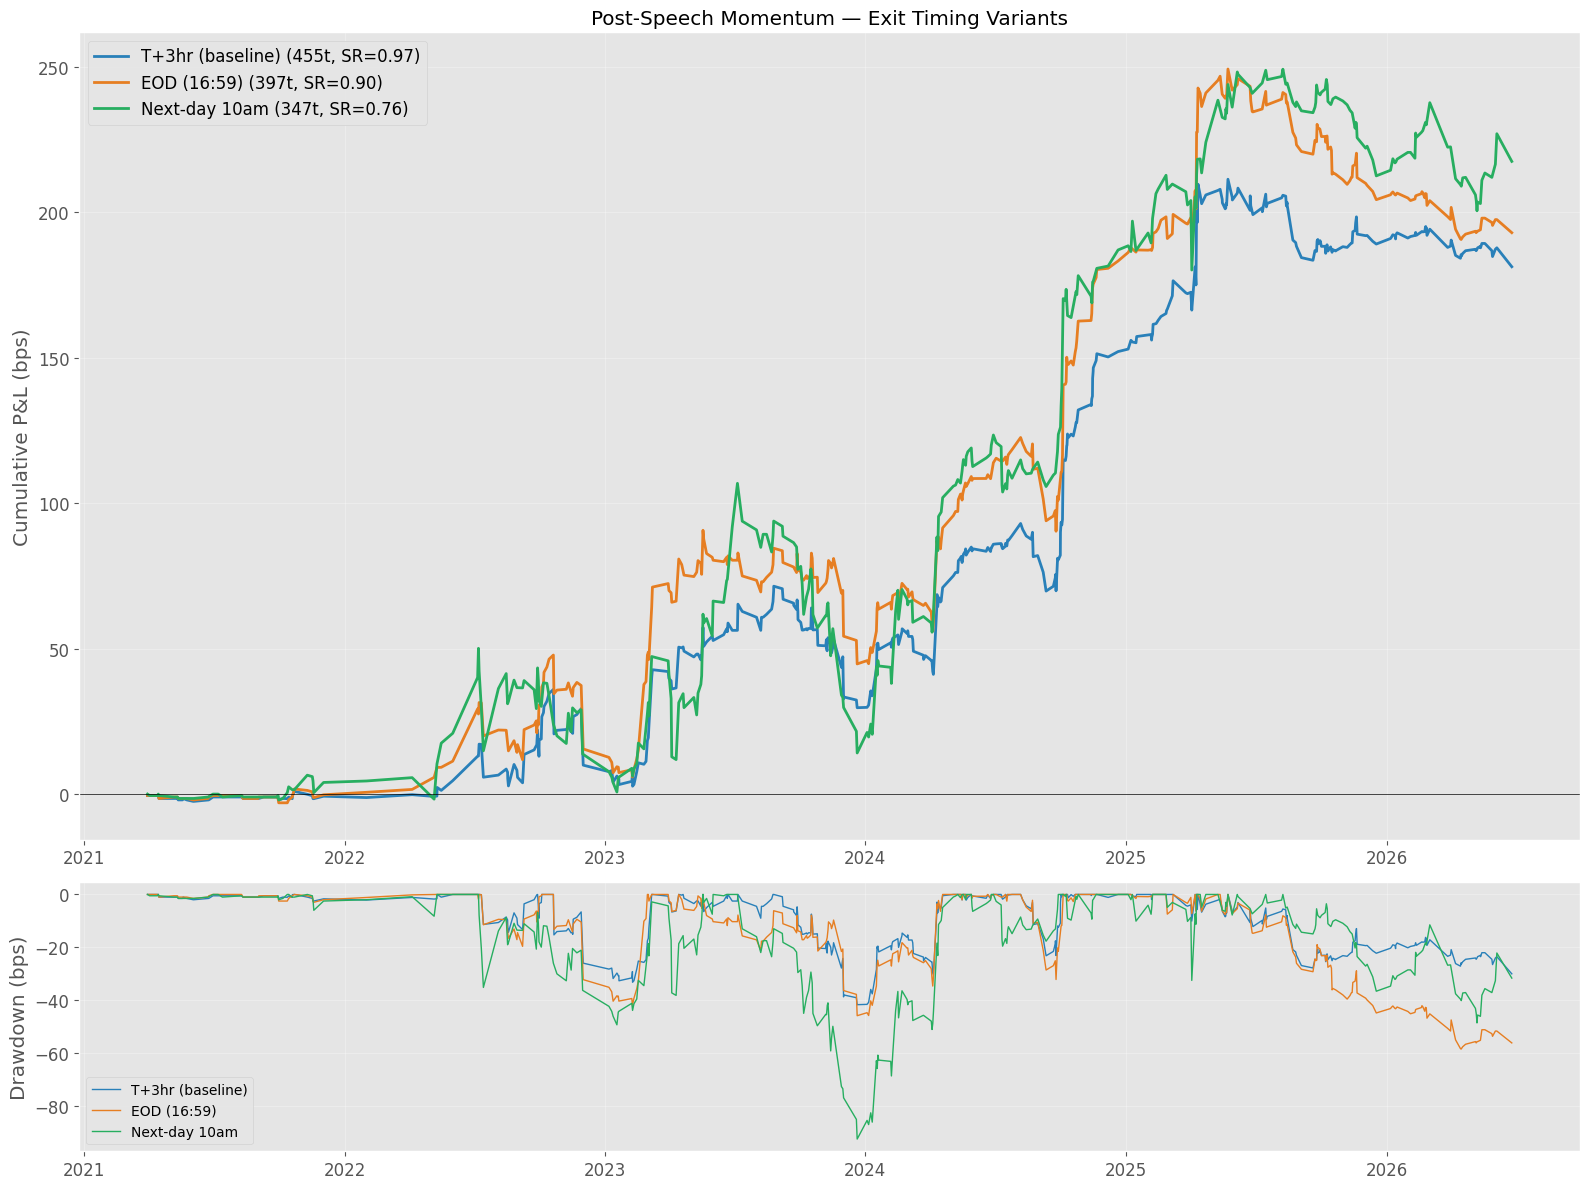

In [5]:
def _sharpe(cl):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs; std = cl["pnl_bps"].std(); avg = cl["pnl_bps"].mean()
    return (avg / std * np.sqrt(tpy)) if std > 0 else 0

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for name in VARIANTS:
    cl = all_closed[name]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=2, color=COLORS[name],
            label=f"{name} ({len(cl)}t, SR={_sharpe(cl):.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)"); ax.set_title("Post-Speech Momentum — Exit Timing Variants")
ax.legend(loc="upper left", fontsize=12); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for name in VARIANTS:
    cl = all_closed[name]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values, lw=1, color=COLORS[name], label=name)
ax2.set_ylabel("Drawdown (bps)"); ax2.legend(loc="lower left", fontsize=10); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Summary Comparison

In [6]:
def calc_stats(cl, name):
    hawk = cl["direction"] == 1
    return {
        "Variant": name, "Trades": len(cl),
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(), "Avg bps": cl["pnl_bps"].mean(),
        "Med bps": cl["pnl_bps"].median(), "Std bps": cl["pnl_bps"].std(),
        "Hit Rate": cl["profitable"].mean(), "Sharpe": _sharpe(cl),
        "Max DD": (cl["cum_bps"] - cl["cum_bps"].cummax()).min(),
        "Skew": cl["pnl_bps"].skew(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    }

rows = [calc_stats(all_closed[n], n) for n in VARIANTS]
summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Skew": "{:+.2f}",
    "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Variant,Trades,Hawk / Dove,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD,Skew,Hawk bps,Dove bps
0,T+3hr (baseline),455,380 / 75,+181.3,+0.398,+0.147,3.83,57.4%,0.97,-41.8,+1.56,+197.3,-16.0
1,EOD (16:59),397,330 / 67,+193.0,+0.486,+0.152,4.70,56.2%,0.90,-58.6,+1.62,+223.1,-30.1
2,Next-day 10am,347,288 / 59,+217.5,+0.627,+0.164,6.71,54.5%,0.76,-92.7,+0.60,+226.3,-8.8


## 6. Calendar-Year Heatmap

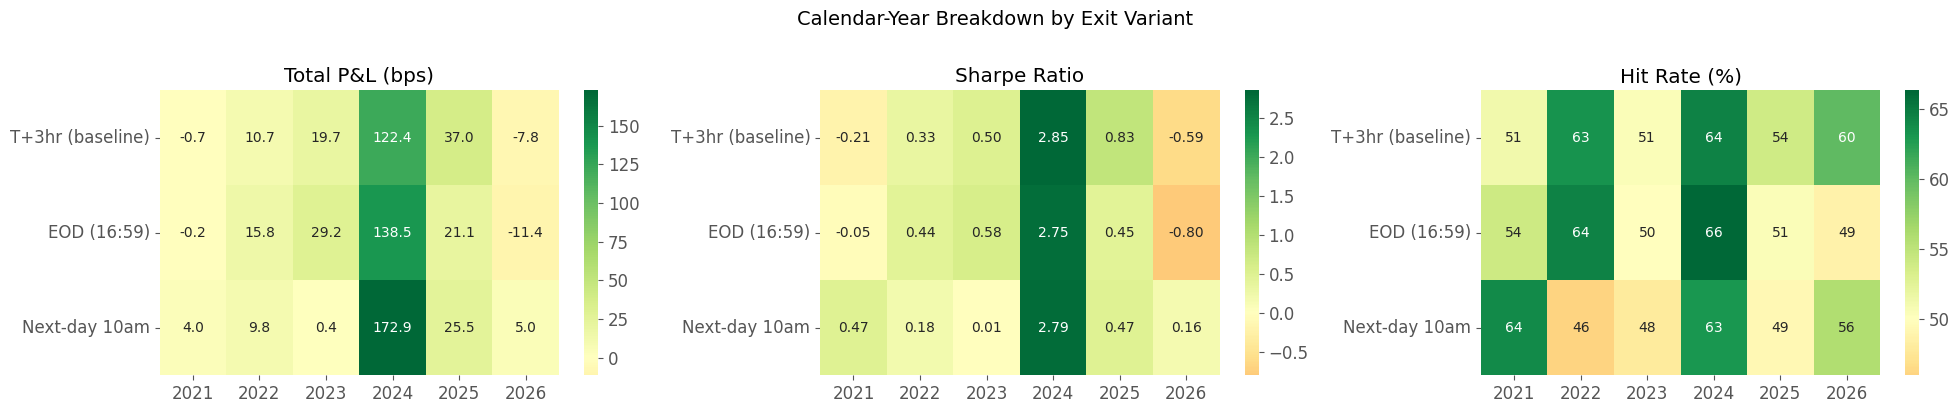

In [7]:
all_years = sorted(set(y for cl in all_closed.values() for y in cl["year"].unique()))
yr_bps = pd.DataFrame(index=list(VARIANTS.keys()), columns=all_years, dtype=float)
yr_sr = yr_bps.copy(); yr_hit = yr_bps.copy()

for name in VARIANTS:
    cl = all_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); avg = grp["pnl_bps"].mean(); std = grp["pnl_bps"].std()
        yr_bps.loc[name, yr] = grp["pnl_bps"].sum()
        yr_sr.loc[name, yr] = (avg / std * np.sqrt(n)) if std > 0 else 0
        yr_hit.loc[name, yr] = grp["profitable"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
sns.heatmap(yr_bps.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)")
sns.heatmap(yr_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio")
sns.heatmap(yr_hit.astype(float)*100, annot=True, fmt=".0f", cmap="RdYlGn", center=50, ax=axes[2])
axes[2].set_title("Hit Rate (%)")
for ax in axes: ax.set_ylabel("")
plt.suptitle("Calendar-Year Breakdown by Exit Variant", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 7. P&L Distribution — Best Variant

Best variant: T+3hr (baseline) (Sharpe=0.97)


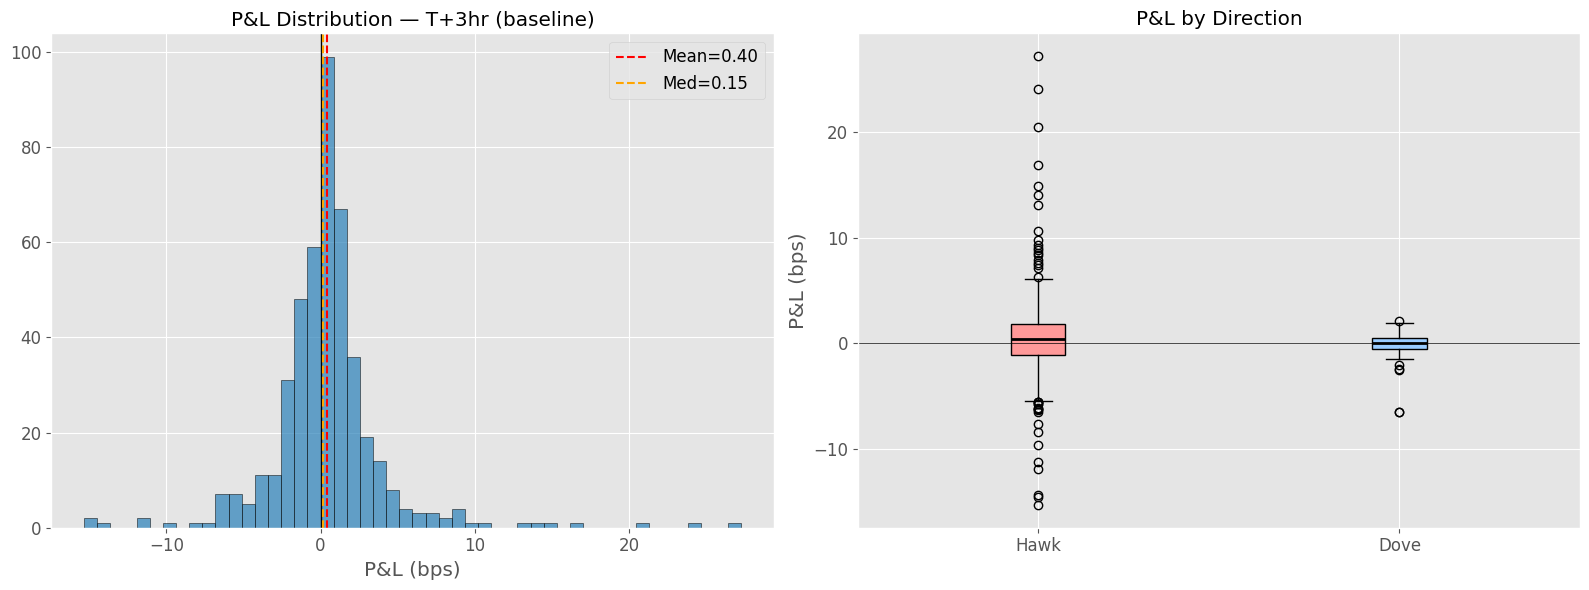

In [8]:
# Pick best variant by Sharpe
best_name = max(VARIANTS.keys(), key=lambda n: _sharpe(all_closed[n]))
cl = all_closed[best_name]
print(f"Best variant: {best_name} (Sharpe={_sharpe(cl):.2f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
ax.hist(cl["pnl_bps"], bins=50, alpha=0.7, color=COLORS[best_name], edgecolor="black")
ax.axvline(0, color="k", lw=1)
avg, med = cl["pnl_bps"].mean(), cl["pnl_bps"].median()
ax.axvline(avg, color="red", ls="--", lw=1.5, label=f"Mean={avg:.2f}")
ax.axvline(med, color="orange", ls="--", lw=1.5, label=f"Med={med:.2f}")
ax.set_xlabel("P&L (bps)"); ax.set_title(f"P&L Distribution — {best_name}"); ax.legend()

ax2 = axes[1]
hawk_bps = cl.loc[cl["direction"] == 1, "pnl_bps"]
dove_bps = cl.loc[cl["direction"] == -1, "pnl_bps"]
bp = ax2.boxplot([hawk_bps, dove_bps], tick_labels=["Hawk", "Dove"], patch_artist=True,
                 medianprops={"color": "black", "lw": 2})
bp["boxes"][0].set_facecolor("#ff9999"); bp["boxes"][1].set_facecolor("#99ccff")
ax2.axhline(0, color="k", lw=0.5); ax2.set_ylabel("P&L (bps)"); ax2.set_title("P&L by Direction")
plt.tight_layout(); plt.show()

## 8. Speaker Attribution — Best Variant

,trades,total_bps,avg_bps,hit_rate
speaker,,,,
Bowman,60,+34.0,+0.567,51.7%
Williams,40,+29.7,+0.742,57.5%
Musalem,20,+27.3,+1.365,70.0%
Logan,16,+24.5,+1.532,56.2%
Waller,39,+22.5,+0.576,66.7%
Powell,31,+20.0,+0.646,67.7%
Collins,5,+19.1,+3.813,100.0%
Barkin,51,+16.7,+0.327,56.9%
Bostic,58,+14.6,+0.251,60.3%


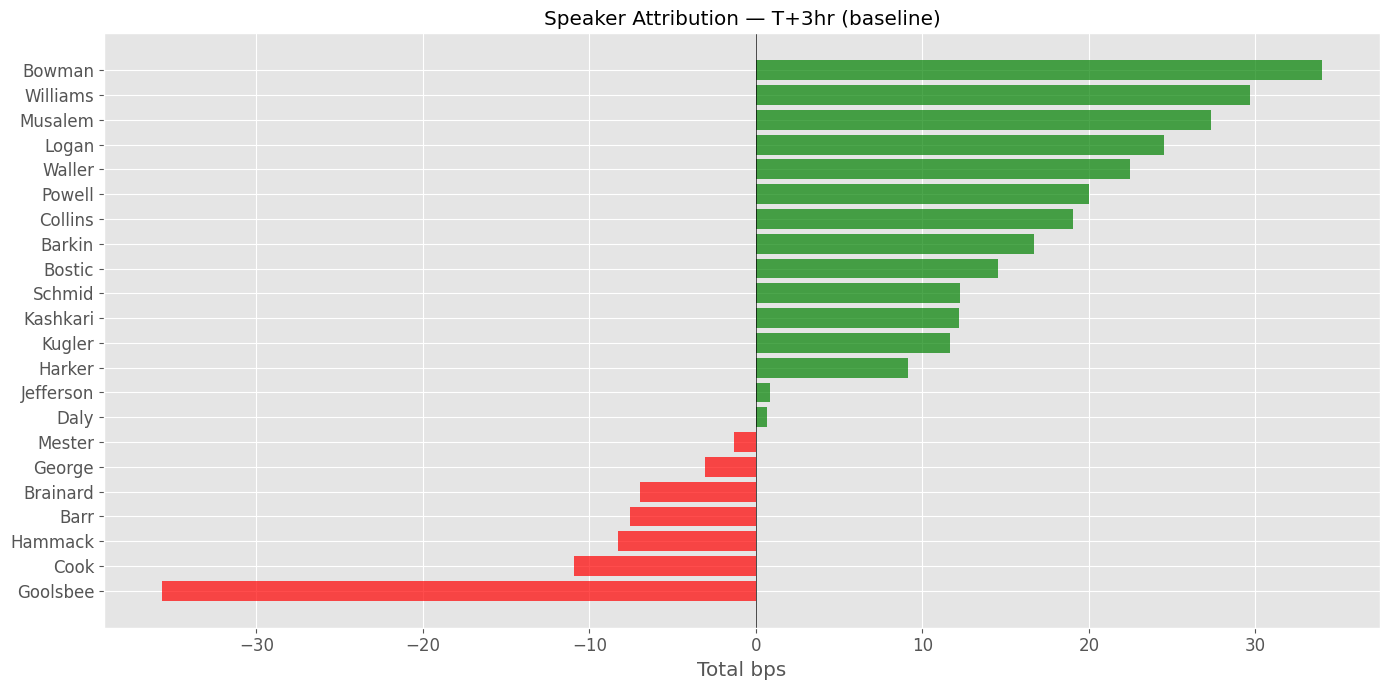

In [9]:
sp = cl.groupby("speaker").agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
).sort_values("total_bps", ascending=False)
display(sp.style.format({"total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(14, 7))
sp_sorted = sp.sort_values("total_bps")
colors = ["green" if x > 0 else "red" for x in sp_sorted["total_bps"]]
ax.barh(sp_sorted.index, sp_sorted["total_bps"], color=colors, alpha=0.7)
ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
ax.set_title(f"Speaker Attribution — {best_name}")
plt.tight_layout(); plt.show()

## 9. Hawk vs Dove Cumulative

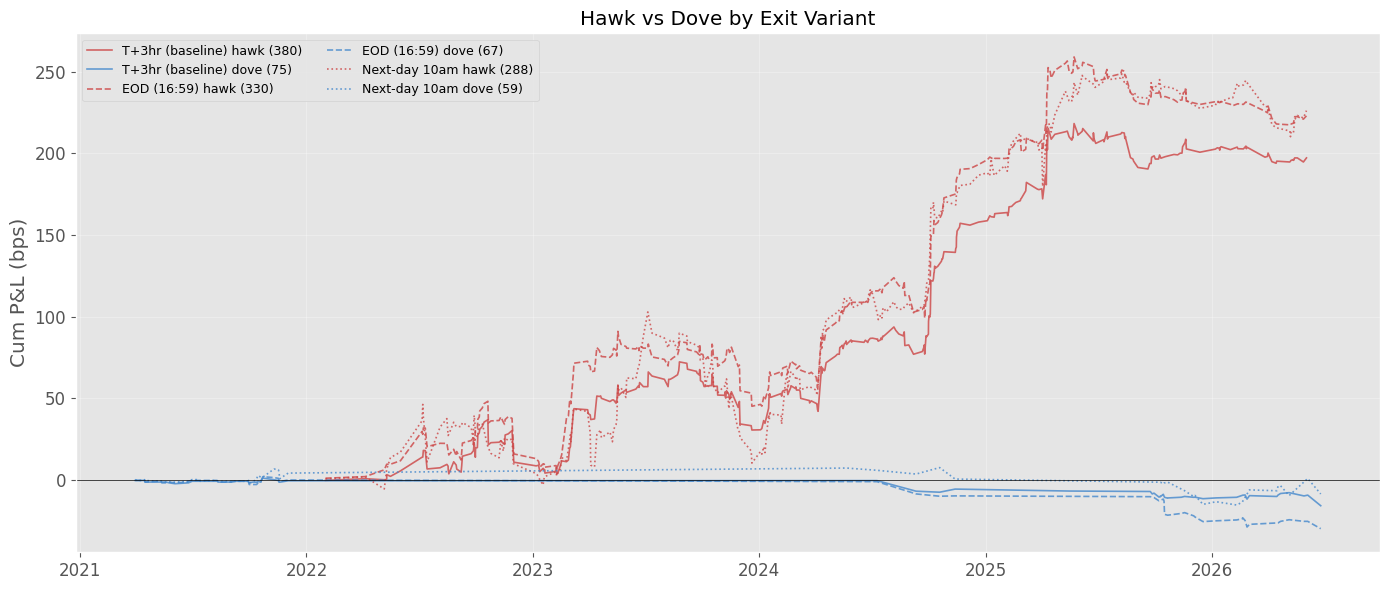

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
for name in VARIANTS:
    cl_v = all_closed[name]
    for d_label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
        mask = cl_v["direction_label"] == d_label
        sub = cl_v[mask].sort_values("opened_at")
        if len(sub) == 0: continue
        ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
                lw=1.2, color=color, ls="-" if "3hr" in name else ("--" if "EOD" in name else ":"),
                label=f"{name} {d_label} ({mask.sum()})", alpha=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cum P&L (bps)"); ax.set_title("Hawk vs Dove by Exit Variant")
ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 10. Hold-Period Return by Hour of Day

In [11]:
# For the baseline variant, does speech time-of-day matter?
cl_base = all_closed["T+3hr (baseline)"]
cl_base["speech_hour"] = cl_base["opened_at"].dt.hour + 1  # entry is T-45min, so speech is ~1hr later
hourly = cl_base.groupby("speech_hour").agg(
    n=("pnl_bps", "count"), total=("pnl_bps", "sum"),
    avg=("pnl_bps", "mean"), hit=("profitable", "mean")
)
print("P&L by speech hour (ET):")
display(hourly.style.format({"total": "{:+.1f}", "avg": "{:+.2f}", "hit": "{:.0%}"}))

P&L by speech hour (ET):


,n,total,avg,hit
speech_hour,,,,
7,12,-2.6,-0.21,67%
8,41,+4.2,+0.10,66%
9,87,+95.2,+1.09,57%
10,67,+34.9,+0.52,57%
11,34,+41.2,+1.21,59%
12,56,+4.2,+0.08,55%
13,60,-28.9,-0.48,48%
14,37,+13.7,+0.37,54%
15,29,+5.8,+0.20,55%


## 11. Morning-Only Filter + Enhanced Variants

Time-of-day analysis shows 9-11am speeches generate ~94% of cumulative P&L (+171 of +181 bps).
Afternoon speeches (1pm+) are net flat or negative. Test morning-only filter combined with
EOD exit and relevance gating.

In [12]:
# Load relevance scores
_rel_cache = {}
for speaker, grp in jpm.groupby("speaker"):
    g = grp.sort_values("date")
    _rel_cache[speaker] = (g["date"].values, g["relevance_scored_pct"].values)

def get_rel(speaker, as_of):
    if speaker not in _rel_cache: return np.nan
    dates, vals = _rel_cache[speaker]
    mask = dates < np.datetime64(as_of)
    return float(vals[mask][-1]) if mask.any() else np.nan

MORNING_CUTOFF = datetime.time(12, 0)  # only speeches before noon ET
REL_GATE = 40

def build_filtered_events(variant_cfg, morning_only=False, rel_gate=None, hawk_only=False):
    mode = variant_cfg["mode"]
    events = []
    for _, row in fed_speak_df.iterrows():
        speaker = extract_speaker(row["Title"])
        if speaker not in KNOWN: continue
        ts = row["TimestampNYC"]
        if pd.isna(ts): continue
        if ts.tzinfo is None: ts = NYC_tz.localize(ts)
        if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH: continue
        if morning_only and ts.time() >= MORNING_CUTOFF: continue
        if is_in_blackout(ts.date()): continue
        if "press conference" in row["Title"].lower(): continue
        t5 = get_t5(speaker, ts.date())
        if pd.isna(t5): continue

        if rel_gate is not None:
            rel = get_rel(speaker, ts.date())
            if pd.isna(rel) or rel < rel_gate: continue

        if t5 >= HAWK_THRESH:
            d = 1
        elif t5 <= -HAWK_THRESH:
            d = -1
        else:
            continue
        if hawk_only and d != 1: continue

        entry = ts - ENTRY_OFFSET
        eq = ql.Date(entry.day, entry.month, entry.year)
        if not ql_cal.isBusinessDay(eq): continue

        if mode == "offset":
            exit_ = ts + datetime.timedelta(minutes=variant_cfg["minutes"])
            exit_ = cap_exit_safe(exit_, entry)
        elif mode == "eod":
            exit_ = NYC_tz.localize(datetime.datetime.combine(ts.date(), datetime.time(16, 59)))
            if exit_ <= entry:
                exit_ = entry + datetime.timedelta(minutes=30)
                exit_ = cap_exit_safe(exit_, entry)
        elif mode == "next_day":
            exit_ = next_bday_10am(ts)
        else:
            continue

        events.append({
            "speaker": speaker, "speech_ts": ts, "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "t5": t5, "bpv": -d * BASE_BPV, "tag": f"e_{len(events)}",
        })
    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last: continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt


ENHANCED = {
    "Baseline T+3hr":           ({"mode": "offset", "minutes": 180}, False, None, False),
    "Morning T+3hr":            ({"mode": "offset", "minutes": 180}, True,  None, False),
    "Morning EOD":              ({"mode": "eod"},                    True,  None, False),
    "Morning+Rel40 T+3hr":      ({"mode": "offset", "minutes": 180}, True,  REL_GATE, False),
    "Morning+Rel40 EOD":        ({"mode": "eod"},                    True,  REL_GATE, False),
    "Morning+Rel40 HawkOnly EOD":({"mode": "eod"},                   True,  REL_GATE, True),
}

ECOLORS = {
    "Baseline T+3hr": "#95a5a6",
    "Morning T+3hr": "#2980b9",
    "Morning EOD": "#e67e22",
    "Morning+Rel40 T+3hr": "#27ae60",
    "Morning+Rel40 EOD": "#8e44ad",
    "Morning+Rel40 HawkOnly EOD": "#c0392b",
}

enhanced_closed = {}
for name, (cfg, morn, rel, hawk_only) in ENHANCED.items():
    evts = build_filtered_events(cfg, morning_only=morn, rel_gate=rel, hawk_only=hawk_only)
    n_h = sum(1 for e in evts if e["direction"] == 1)
    n_d = sum(1 for e in evts if e["direction"] == -1)
    print(f"{name:35s}: {len(evts):4d} events (H={n_h}, D={n_d})")
    bt = run_bt(evts, name)
    cl = extract_closed(bt)
    enhanced_closed[name] = cl

print("\nAll enhanced variants complete.")

Baseline T+3hr                     :  461 events (H=386, D=75)


  Baseline T+3hr:   0%|          | 0/916 [00:00<?, ?step/s]

  Baseline T+3hr:   0%|          | 1/916 [00:00<03:43,  4.10step/s]

  Baseline T+3hr:   0%|          | 4/916 [00:00<01:06, 13.66step/s]

  Baseline T+3hr:   1%|          | 7/916 [00:00<00:52, 17.22step/s]

...

  Morning+Rel40 HawkOnly EOD:  97%|█████████▋| 341/350 [00:13<00:00, 25.43step/s]

  Morning+Rel40 HawkOnly EOD:  98%|█████████▊| 344/350 [00:14<00:00, 26.57step/s]

  Morning+Rel40 HawkOnly EOD:  99%|█████████▉| 347/350 [00:14<00:00, 25.62step/s]

  Morning+Rel40 HawkOnly EOD: 100%|██████████| 350/350 [00:14<00:00, 24.46step/s]


All enhanced variants complete.


## 12. Enhanced Variants — Summary & Equity Curves

,Variant,Trades,H / D,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD,Skew,Hawk bps,Dove bps
0,Baseline T+3hr,455,380/75,+181.3,+0.398,+0.147,3.83,57.4%,0.97,-41.8,+1.56,+197.3,-16.0
1,Morning T+3hr,243,204/39,+173.6,+0.714,+0.435,4.82,59.3%,1.01,-35.8,+1.42,+185.8,-12.2
2,Morning EOD,243,204/39,+225.3,+0.927,+0.437,5.63,57.2%,1.12,-45.6,+1.46,+253.1,-27.8
3,Morning+Rel40 T+3hr,189,174/15,+153.4,+0.812,+0.482,5.10,58.7%,0.96,-27.0,+1.59,+161.0,-7.5
4,Morning+Rel40 EOD,189,174/15,+186.1,+0.985,+0.208,5.89,54.0%,1.01,-34.3,+1.56,+206.7,-20.6
5,Morning+Rel40 HawkOnly EOD,175,175/0,+206.6,+1.181,+0.526,6.04,56.0%,1.28,-33.0,+1.49,+206.6,+0.0


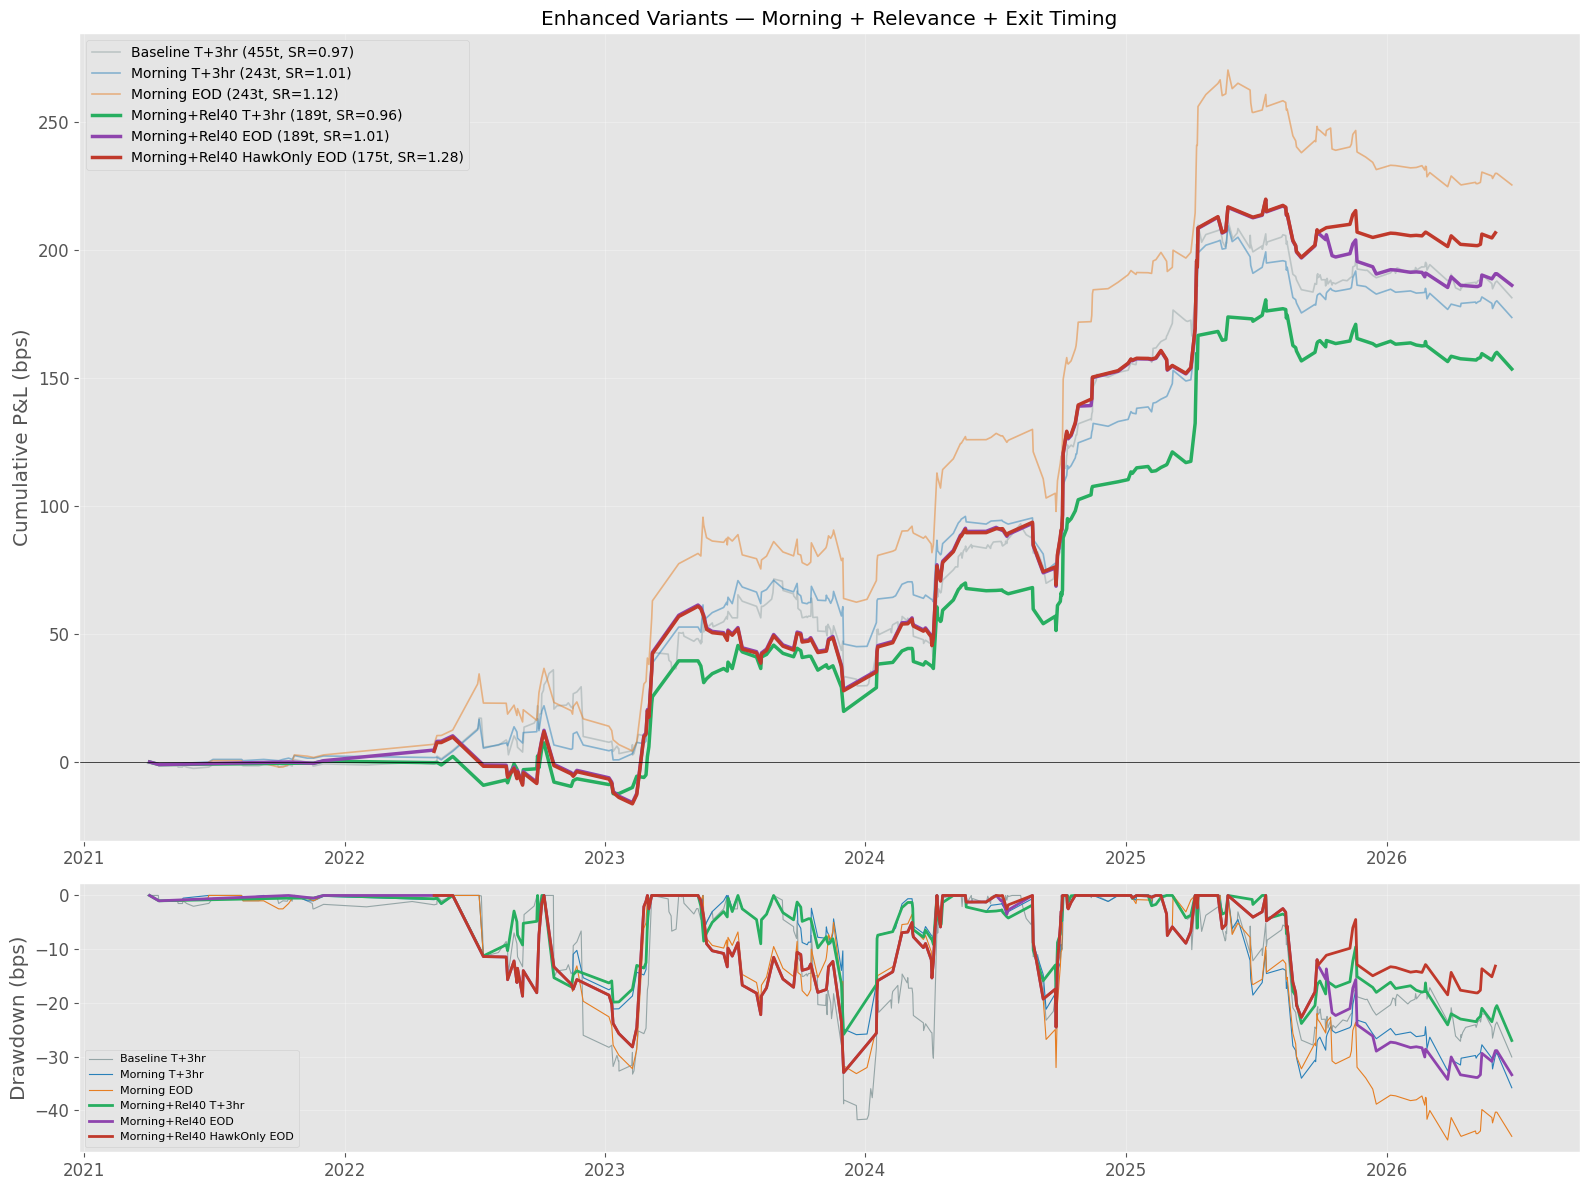

In [13]:
rows = []
for name in ENHANCED:
    cl = enhanced_closed[name]
    hawk = cl["direction"] == 1
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs; std = cl["pnl_bps"].std(); avg = cl["pnl_bps"].mean()
    sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
    dd = (cl["cum_bps"] - cl["cum_bps"].cummax()).min()
    rows.append({
        "Variant": name, "Trades": n,
        "H / D": f"{hawk.sum()}/{(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(), "Avg bps": avg,
        "Med bps": cl["pnl_bps"].median(), "Std bps": std,
        "Hit Rate": cl["profitable"].mean(), "Sharpe": sr,
        "Max DD": dd, "Skew": cl["pnl_bps"].skew(),
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum() if (~hawk).any() else 0,
    })
enh_df = pd.DataFrame(rows)
display(enh_df.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Skew": "{:+.2f}",
    "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

# Equity curves
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
for name in ENHANCED:
    cl = enhanced_closed[name]
    sr = _sharpe(cl)
    lw = 2.5 if "Rel40" in name else 1.2
    alpha = 1.0 if "Rel40" in name else 0.5
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=lw, color=ECOLORS[name], alpha=alpha,
            label=f"{name} ({len(cl)}t, SR={sr:.2f})")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Enhanced Variants — Morning + Relevance + Exit Timing")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
for name in ENHANCED:
    cl = enhanced_closed[name]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    lw = 2 if "Rel40" in name else 0.8
    ax2.plot(cl["opened_at"].values, dd.values, lw=lw, color=ECOLORS[name], label=name)
ax2.set_ylabel("Drawdown (bps)"); ax2.legend(loc="lower left", fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

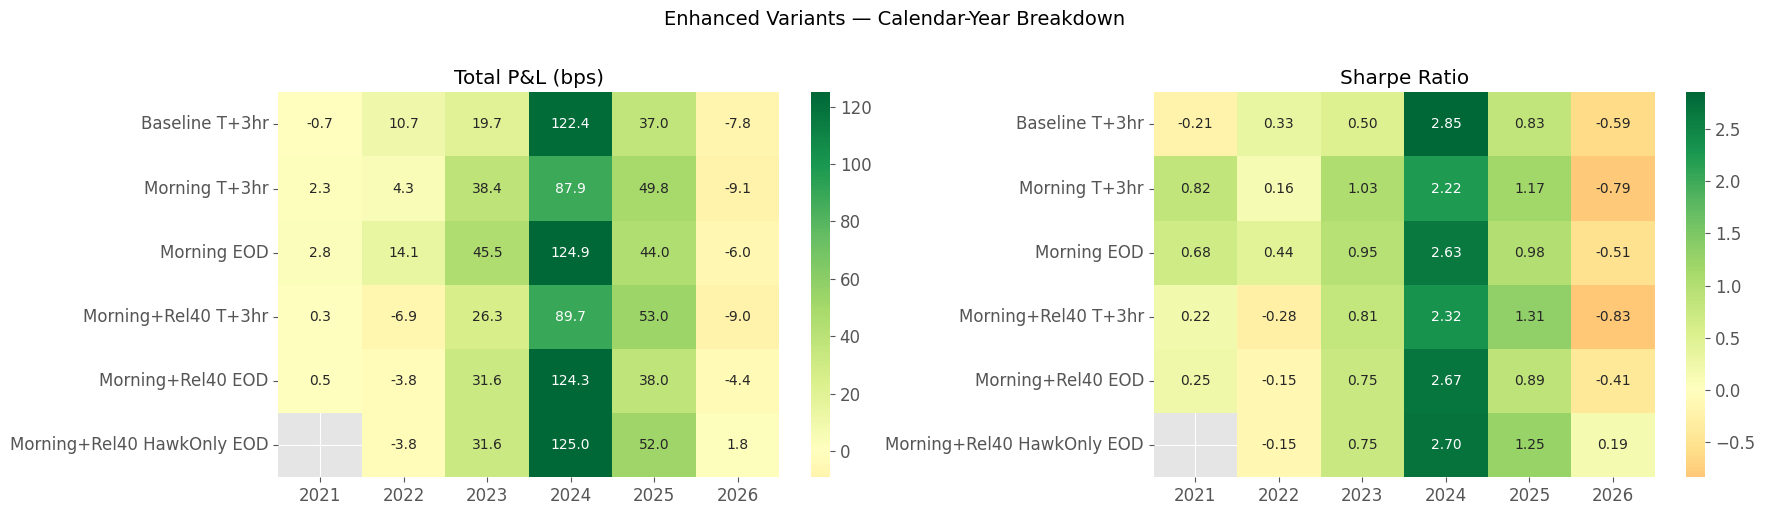

In [14]:
# Calendar year heatmap for enhanced variants
all_years_e = sorted(set(y for cl in enhanced_closed.values() for y in cl["year"].unique()))
yr_bps_e = pd.DataFrame(index=list(ENHANCED.keys()), columns=all_years_e, dtype=float)
yr_sr_e = yr_bps_e.copy()

for name in ENHANCED:
    cl = enhanced_closed[name]
    for yr, grp in cl.groupby("year"):
        n = len(grp); avg = grp["pnl_bps"].mean(); std = grp["pnl_bps"].std()
        yr_bps_e.loc[name, yr] = grp["pnl_bps"].sum()
        yr_sr_e.loc[name, yr] = (avg / std * np.sqrt(n)) if std > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.heatmap(yr_bps_e.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)"); axes[0].set_ylabel("")
sns.heatmap(yr_sr_e.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio"); axes[1].set_ylabel("")
plt.suptitle("Enhanced Variants — Calendar-Year Breakdown", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()